In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")

print("Path to dataset files:", path)

/Users/diy-101/Git_repositories/data_analysis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 15.8k/15.8k [00:00<00:00, 1.18MB/s]

Extracting files...
Path to dataset files: /Users/diy-101/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import sklearn as sk
import os
import warnings
import scipy as sci
warnings.filterwarnings("ignore")

In [6]:
data = pd.read_csv(path+"/Teen_Mental_Health_Dataset.csv")

# EDA

In [7]:
data.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [9]:
data.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [10]:
len(data)

1200

In [87]:
data.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [ ]:
target_name = "stress_level"
target = data[target_name]
features = data.drop(columns=[target_name])
num_features = features.select_dtypes(exclude=["object"])
cat_features = features.select_dtypes(include=["object"])

target.unique()

array([ 2,  8,  1,  3,  6,  5,  4, 10,  9,  7])

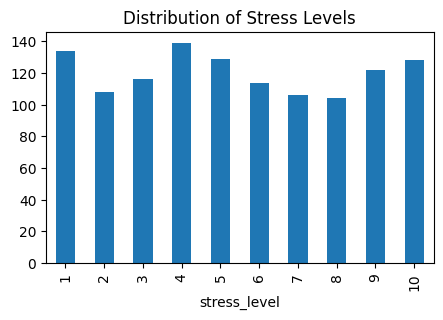

In [ ]:
plt.figure(figsize=(5, 3))

target.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Stress Levels")
plt.show()

In [30]:
num_features

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,anxiety_level,addiction_level,depression_label
0,14,7.9,7.4,2.9,3.01,1.5,2,1,0
1,19,1.9,8.0,2.9,3.22,0.8,1,10,0
2,17,1.3,7.6,0.5,3.92,0.0,4,2,0
3,15,7.4,6.9,1.6,3.48,0.8,7,9,0
4,15,4.7,4.9,3.0,2.37,1.4,5,2,0
...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,4,4,0
1196,16,2.3,8.0,1.9,2.12,0.4,4,4,0
1197,14,1.7,8.7,0.7,3.98,0.8,1,1,0
1198,15,3.9,8.5,2.1,3.19,0.6,9,9,0


<Axes: >

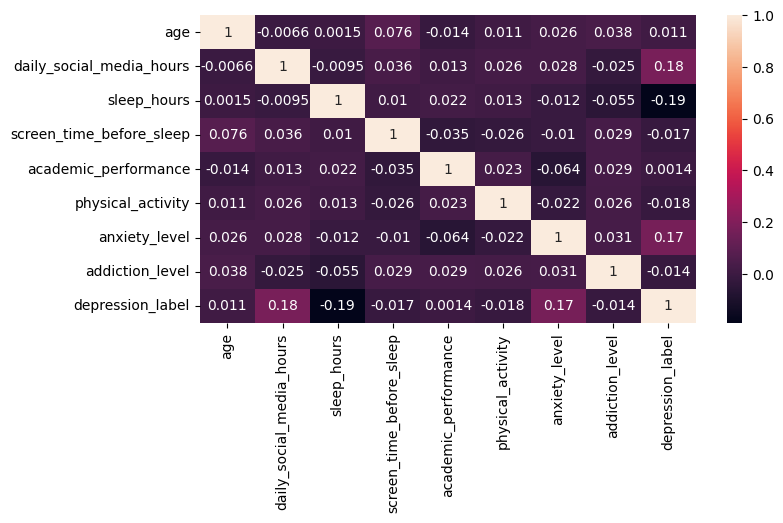

In [36]:
plt.figure(figsize=(8, 4))
sns.heatmap(data=num_features.corr(), annot=True)

In [ ]:
rs, ps = sci.stats.spearmanr(num_features["anxiety_level"], target)
rp, pp = sci.stats.pearsonr(num_features["anxiety_level"], target)
rk, pk = sci.stats.kendalltau(num_features["anxiety_level"], target)

print(f"Spearman correlation: {rs:.5f}, p-value: {ps:.5f}")
print(f"Pearson correlation: {rp:.5f}, p-value: {pp:.5f}")
print(f"Kendall's tau: {rk:.5f}, p-value: {pk:.5f}")

Spearman correlation: 0.01633, p-value: 0.57205
Pearson correlation: 0.01581, p-value: 0.58425
Kendall's tau: 0.01243, p-value: 0.55762


In [62]:
cat_features

,gender,platform_usage,social_interaction_level
0,male,Instagram,low
1,female,TikTok,high
2,female,Instagram,high
3,male,TikTok,medium
4,female,Both,medium
...,...,...,...
1195,female,Instagram,low
1196,male,Both,high
1197,female,Both,high
1198,male,Both,high


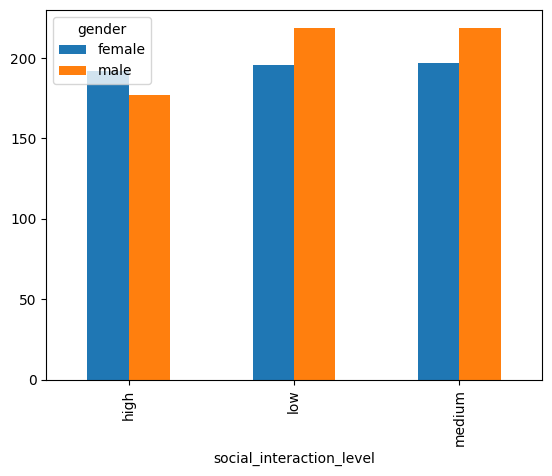

In [84]:
cross = pd.crosstab(cat_features['social_interaction_level'], cat_features["gender"])
cross.plot(kind="bar")
plt.show()

In [85]:
chi2, pvalue, dof, expected = sci.stats.chi2_contingency(cross)
print(f"Chi-squared statistic: {chi2:.5f}, p-value: {pvalue:.5f}")

Chi-squared statistic: 2.29935, p-value: 0.31674


array([[189, 203, 193],
       [202, 208, 205]])